In [2]:
pip install autots

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.6 MB/s eta 0:00:00


In [3]:
pip install prophet

In [4]:
pip install xgboost

In [33]:
# Prophet imports
import prophet
from prophet import Prophet
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric

# ARIMA imports
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA

# LSTM imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from keras import ops

#XGB imports
import xgboost as xgb

from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import zscore
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error,
                             mean_absolute_percentage_error,
                             root_mean_squared_error)

In [6]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#loading data
data = pd.read_csv("/content/drive/MyDrive/Intelligence Tech Solutions /Foreign_Exchange_Rates.xls")
data

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5212,5212,25-12-2019,ND,ND,ND,ND,ND,ND,ND,ND,...,ND,ND,ND,ND,ND,ND,ND,ND,ND,NaN
5213,5213,26-12-2019,1.4411,0.9007,1.5002,0.7688,4.0602,1.3124,6.9949,7.788,...,6.7295,109.67,4.1337,8.8799,9.4108,181.3,0.9808,30.11,30.15,NaN
5214,5214,27-12-2019,1.4331,0.8949,1.4919,0.7639,4.0507,1.3073,6.9954,7.7874,...,6.6829,109.47,4.126,8.8291,9.3405,181.35,0.9741,30.09,30.14,NaN
5215,5215,30-12-2019,1.4278,0.8915,1.4846,0.761,4.0152,1.3058,6.9864,7.7857,...,6.6589,108.85,4.1053,8.7839,9.3145,181.6,0.9677,30.04,29.94,NaN


In [8]:
data.isnull().sum()

,0
Unnamed: 0,0
Time Serie,0
AUSTRALIA - AUSTRALIAN DOLLAR/US$,0
EURO AREA - EURO/US$,0
NEW ZEALAND - NEW ZELAND DOLLAR/US$,0
UNITED KINGDOM - UNITED KINGDOM POUND/US$,0
BRAZIL - REAL/US$,0
CANADA - CANADIAN DOLLAR/US$,0
CHINA - YUAN/US$,0
HONG KONG - HONG KONG DOLLAR/US$,0


In [9]:
data = data.drop(columns=['Unnamed: 24', 'Unnamed: 0'])

In [10]:
#dropping null values and converting timeseries to datetime
data.dropna(inplace=True)
data['Time Serie'] = pd.to_datetime(data['Time Serie'], format='%d-%m-%Y')
print(f"Data Shape:{data.shape}")

Data Shape:(5217, 23)


# **Pre-processing**

In [11]:
#Pre-Processing code here
# Columns are listed as object as there are rows containing string word 'ND'
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Time Serie                                 5217 non-null   datetime64[ns]
 1   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   object        
 2   EURO AREA - EURO/US$                       5217 non-null   object        
 3   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   object        
 4   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object        
 5   BRAZIL - REAL/US$                          5217 non-null   object        
 6   CANADA - CANADIAN DOLLAR/US$               5217 non-null   object        
 7   CHINA - YUAN/US$                           5217 non-null   object        
 8   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   object        
 9   INDIA - INDIAN RUPE

In [12]:
# 'ND' are replaced as NAs
data.replace('ND', np.nan, inplace=True)
#Percentage of NAs across each feature after converting 'ND' as NA
data.isnull().sum()/data.shape[0]*100

,0
Time Serie,0.000000
AUSTRALIA - AUSTRALIAN DOLLAR/US$,3.795285
EURO AREA - EURO/US$,3.795285
NEW ZEALAND - NEW ZELAND DOLLAR/US$,3.795285
UNITED KINGDOM - UNITED KINGDOM POUND/US$,3.795285
BRAZIL - REAL/US$,3.795285
CANADA - CANADIAN DOLLAR/US$,3.795285
CHINA - YUAN/US$,3.776117
HONG KONG - HONG KONG DOLLAR/US$,3.795285
INDIA - INDIAN RUPEE/US$,3.814453


In [13]:
# 202 rows have been dropped
data.dropna(inplace=True)
print(f"Data Shape:{data.shape}")

Data Shape:(5015, 23)


In [14]:
data.info()
# Listing all columns that are classified as object.
cols = ['AUSTRALIA - AUSTRALIAN DOLLAR/US$', 'EURO AREA - EURO/US$',
        'NEW ZEALAND - NEW ZELAND DOLLAR/US$', 'UNITED KINGDOM - UNITED KINGDOM POUND/US$',
        'BRAZIL - REAL/US$', 'CANADA - CANADIAN DOLLAR/US$',
        'CHINA - YUAN/US$', 'HONG KONG - HONG KONG DOLLAR/US$',
        'INDIA - INDIAN RUPEE/US$', 'KOREA - WON/US$',
        'MEXICO - MEXICAN PESO/US$', 'SOUTH AFRICA - RAND/US$',
        'SINGAPORE - SINGAPORE DOLLAR/US$', 'DENMARK - DANISH KRONE/US$',
        'JAPAN - YEN/US$', 'MALAYSIA - RINGGIT/US$',
        'NORWAY - NORWEGIAN KRONE/US$', 'SWEDEN - KRONA/US$',
        'SRI LANKA - SRI LANKAN RUPEE/US$', 'SWITZERLAND - FRANC/US$',
        'TAIWAN - NEW TAIWAN DOLLAR/US$', 'THAILAND - BAHT/US$']

<class 'pandas.core.frame.DataFrame'>
Index: 5015 entries, 0 to 5216
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Time Serie                                 5015 non-null   datetime64[ns]
 1   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5015 non-null   object        
 2   EURO AREA - EURO/US$                       5015 non-null   object        
 3   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5015 non-null   object        
 4   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5015 non-null   object        
 5   BRAZIL - REAL/US$                          5015 non-null   object        
 6   CANADA - CANADIAN DOLLAR/US$               5015 non-null   object        
 7   CHINA - YUAN/US$                           5015 non-null   object        
 8   HONG KONG - HONG KONG DOLLAR/US$           5015 non-null   object        
 9   INDIA - INDIAN RUPEE/US$

In [15]:
# Changing Dtype to float.
data[cols] = data[cols].apply(pd.to_numeric, errors='coerce')
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5015 entries, 0 to 5216
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Time Serie                                 5015 non-null   datetime64[ns]
 1   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5015 non-null   float64       
 2   EURO AREA - EURO/US$                       5015 non-null   float64       
 3   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5015 non-null   float64       
 4   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5015 non-null   float64       
 5   BRAZIL - REAL/US$                          5015 non-null   float64       
 6   CANADA - CANADIAN DOLLAR/US$               5015 non-null   float64       
 7   CHINA - YUAN/US$                           5015 non-null   float64       
 8   HONG KONG - HONG KONG DOLLAR/US$           5015 non-null   float64       
 9   INDIA - INDIAN RUPEE/US$

In [16]:
if data.duplicated().sum() >0:
    print(f"Duplicates: {data.duplicated().sum()}")
else:
    print("No duplicates found")

No duplicates found


# **EDA**

In [17]:
# EDA code here
# At first glance, Korea appears to have the larget std.
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Time Serie,5015,2009-12-25 16:30:54.915254272,2000-01-03 00:00:00,2004-12-28 12:00:00,2009-12-22 00:00:00,2014-12-22 12:00:00,2019-12-31 00:00:00,NaN
AUSTRALIA - AUSTRALIAN DOLLAR/US$,5015.0,1.33216,0.9069,1.1152,1.3113,1.4304,2.0713,0.269974
EURO AREA - EURO/US$,5015.0,0.844014,0.6246,0.751,0.8156,0.90015,1.2092,0.126826
NEW ZEALAND - NEW ZELAND DOLLAR/US$,5015.0,1.54382,1.1346,1.3238,1.4426,1.5912,2.551,0.337414
UNITED KINGDOM - UNITED KINGDOM POUND/US$,5015.0,0.640466,0.4738,0.5875,0.6365,0.6924,0.8287,0.082562
BRAZIL - REAL/US$,5015.0,2.548483,1.5375,1.94565,2.3291,3.13,4.2594,0.724234
CANADA - CANADIAN DOLLAR/US$,5015.0,1.230503,0.9168,1.05585,1.2371,1.3357,1.6128,0.182136
CHINA - YUAN/US$,5015.0,7.200544,6.0402,6.47555,6.86,8.2765,8.28,0.820413
HONG KONG - HONG KONG DOLLAR/US$,5015.0,7.782643,7.7085,7.7564,7.7806,7.7998,7.8499,0.027551
INDIA - INDIAN RUPEE/US$,5015.0,52.726249,38.48,45.25,48.1,62.44,74.33,9.678708


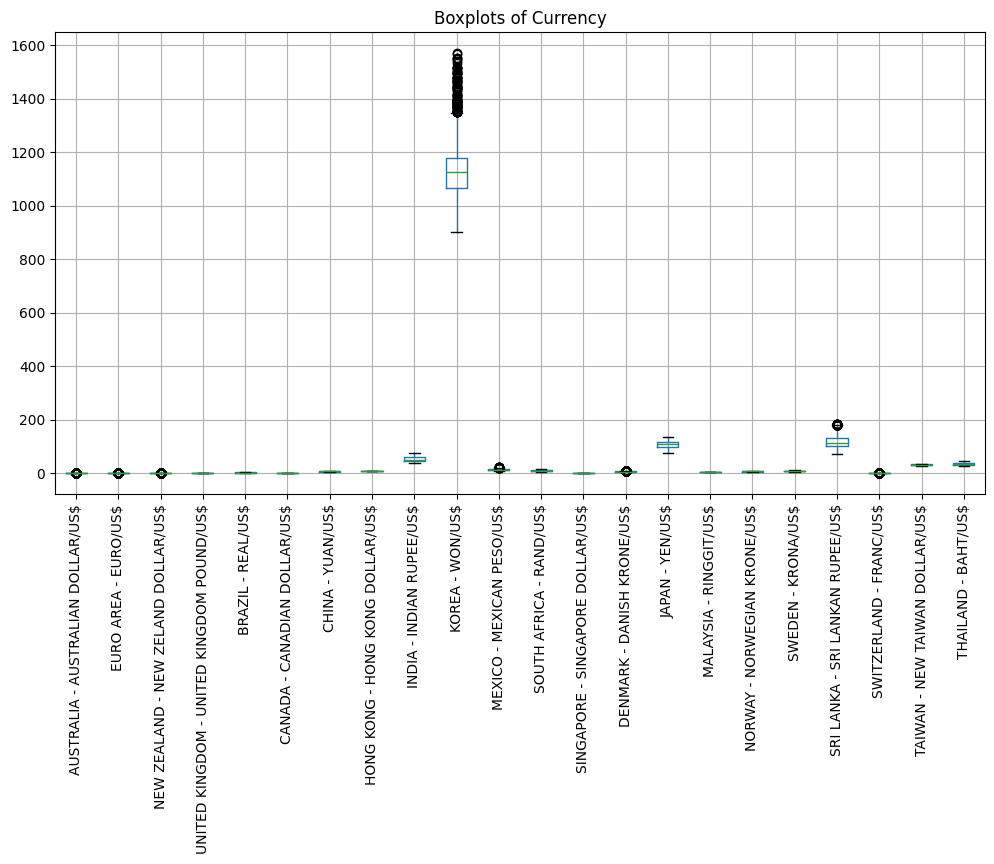

In [18]:
# Large number of outlier found in Korea.
data.select_dtypes(include='number').boxplot(figsize=(12, 6))
plt.xticks(rotation=90)
plt.title('Boxplots of Currency')
plt.show()

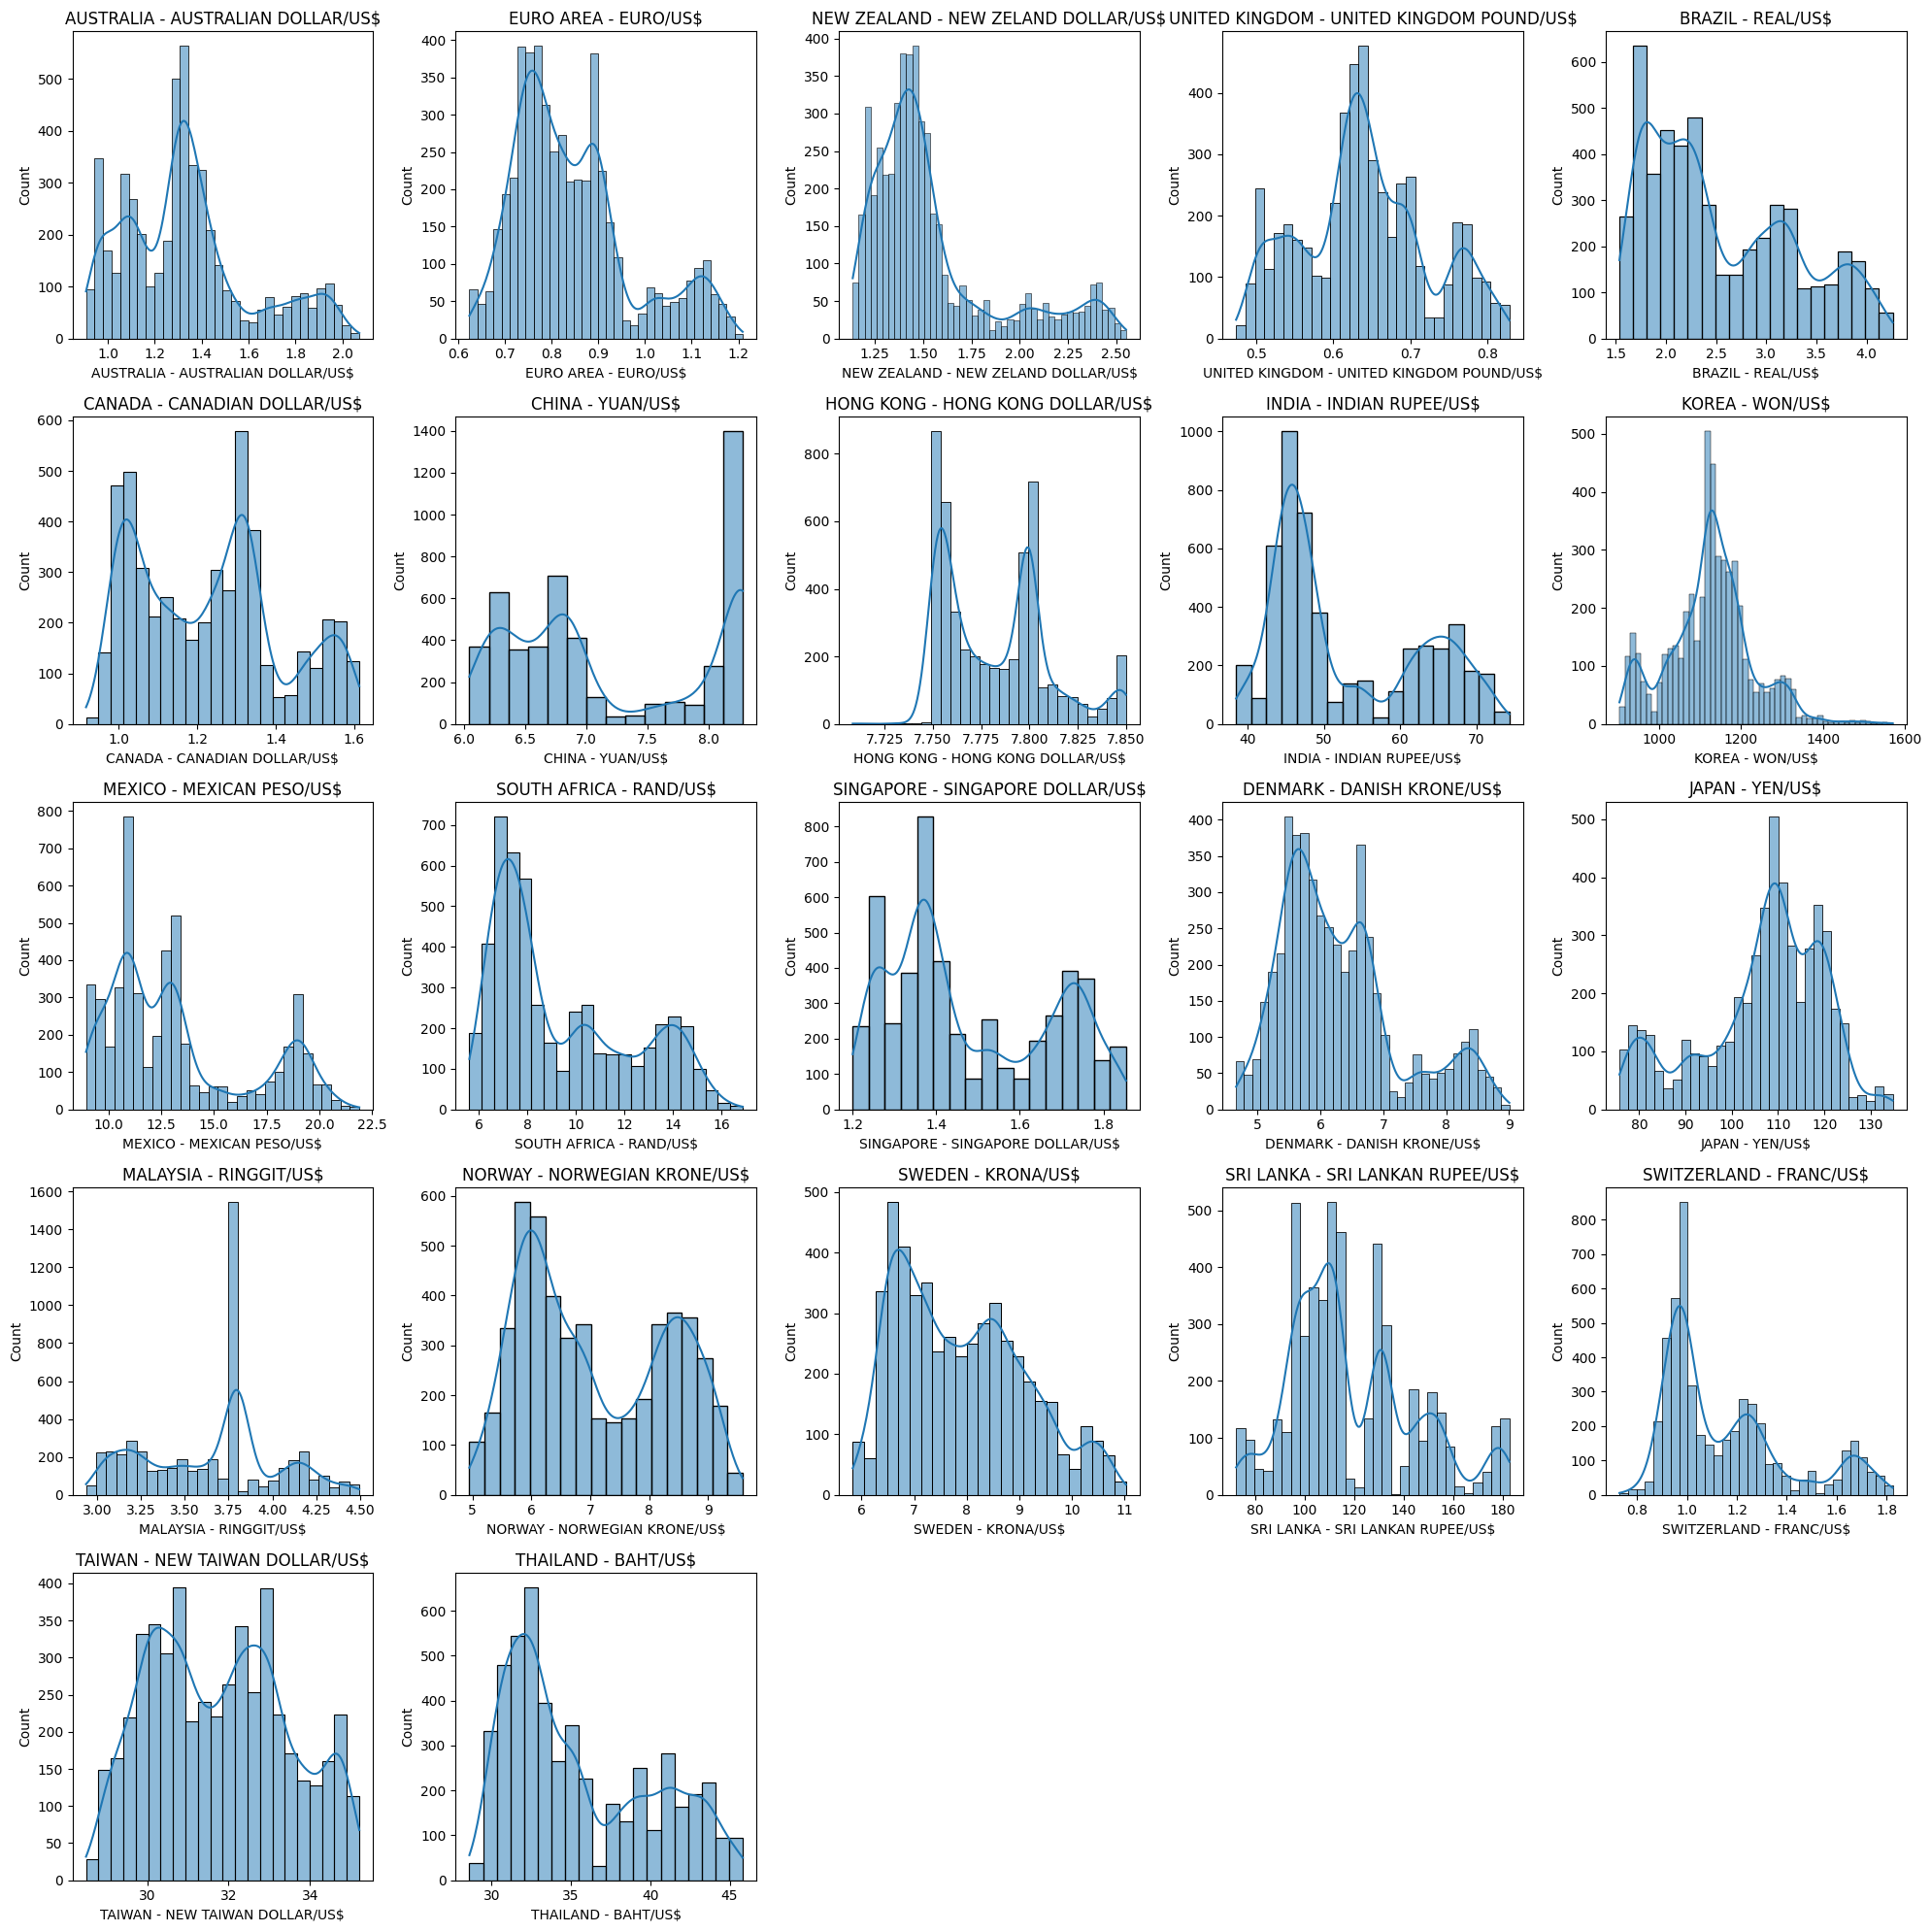

In [19]:
# Distribution of currency
# Korean has positive skew.
num_cols = data.select_dtypes(include='number').columns

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=data, x=col, ax=axes[i], kde= True)
    axes[i].set_title(col)

# Remove empty subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

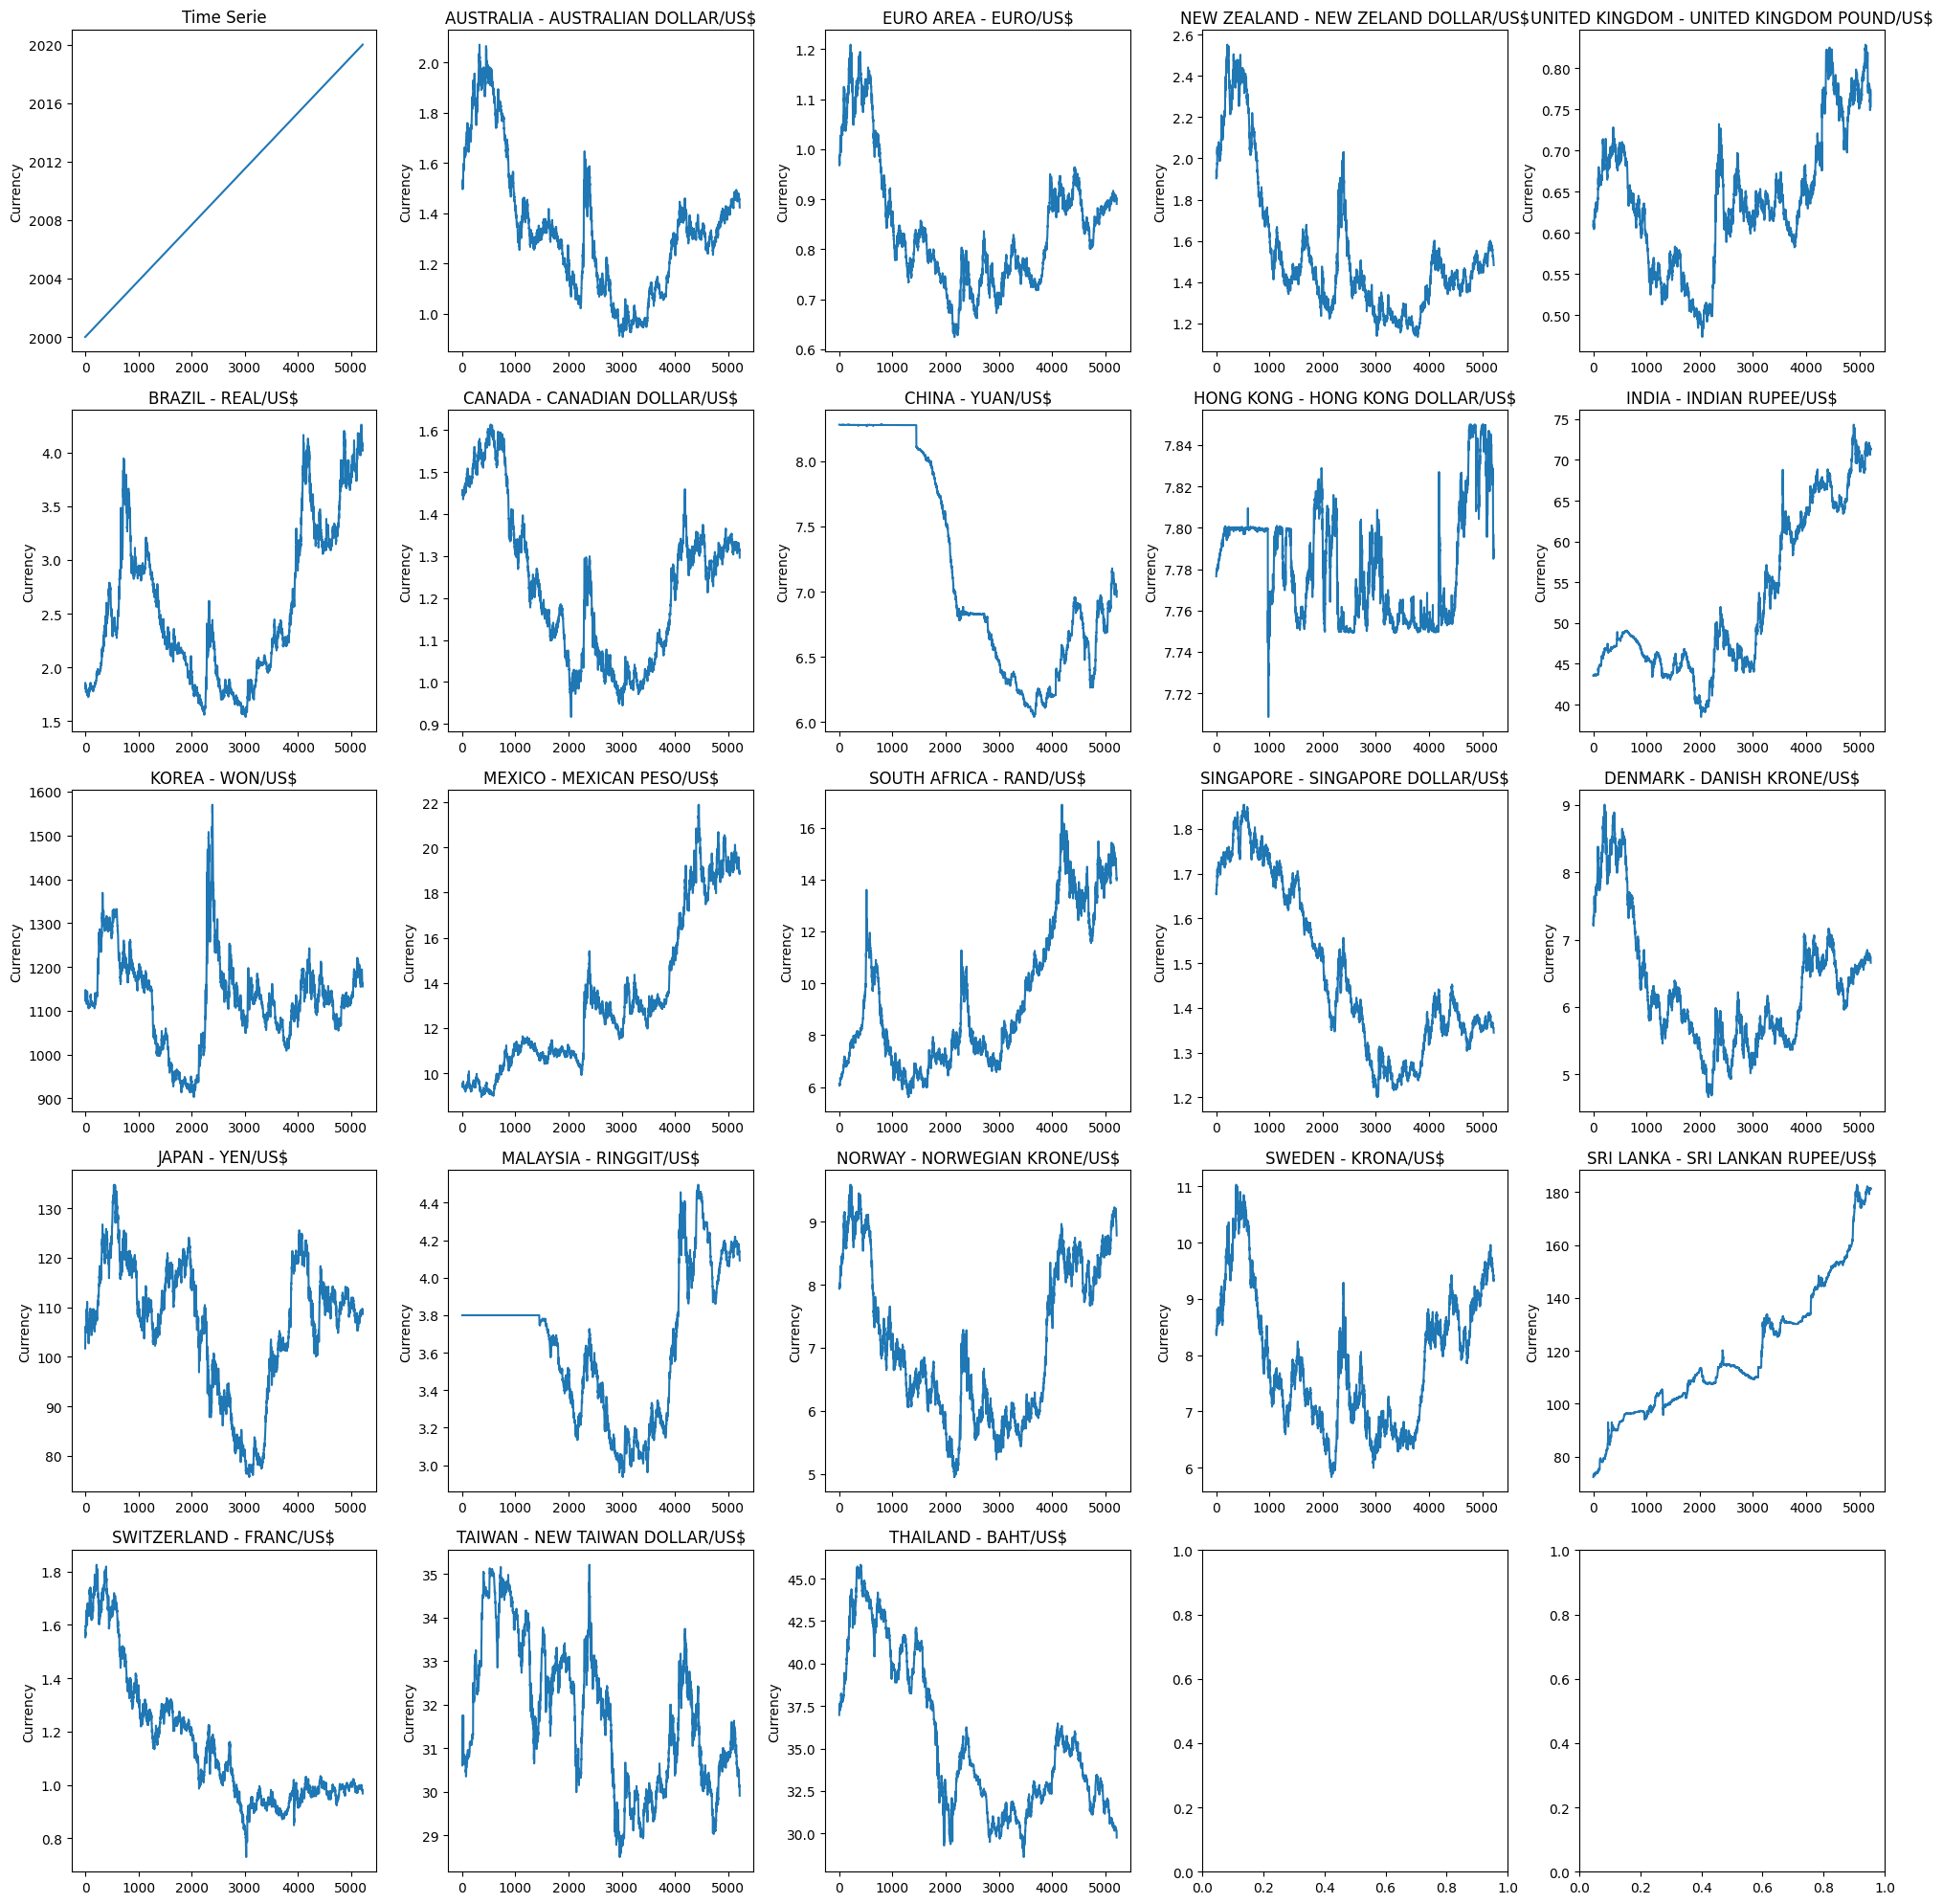

In [20]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))

axes_flat = axes.flatten()

for i, col_name in enumerate(data.columns):
    if i < 25:
        ax = axes_flat[i]
        ax.plot(data[col_name])
        ax.set_title(col_name)
        ax.set_ylabel("Currency")
    else:
        break

plt.tight_layout()
plt.show()

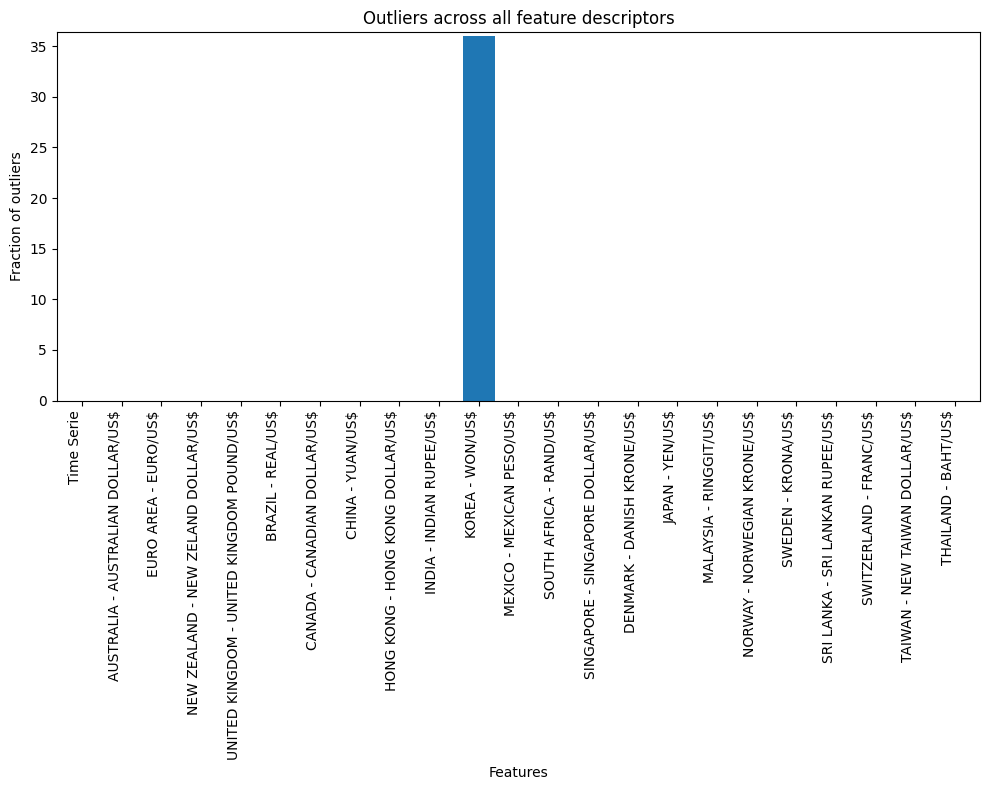

In [21]:
# Outlier % of each feature
outlier_counts = []

for col in data.columns:
    z = np.abs(zscore(data[col].dropna()))
    outlier_counts.append((z > 3).sum())

plt.figure(figsize=(10, 8))
plt.bar(data.columns, outlier_counts)
plt.xticks(rotation=90, ha='right')
plt.subplots_adjust(bottom = 0.1)
plt.margins(0.01)
plt.xlabel("Features")
plt.ylabel("Fraction of outliers")
plt.title("Outliers across all feature descriptors")
plt.tight_layout()
plt.show()

In [22]:
# Outlier removal
# Defining the 25%, 50% and 75% quartiles.
Q1 = data['KOREA - WON/US$'].quantile(0.25)
Q3 = data['KOREA - WON/US$'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

# Get the actual index labels of the rows that are outliers
upper_outlier_indices = data.index[np.where(data['KOREA - WON/US$'] >= upper)[0]]
lower_outlier_indices = data.index[np.where(data['KOREA - WON/US$'] <= lower)[0]]

# This removes outliers outside the standard deviation.
data.drop(index=upper_outlier_indices, inplace=True)
data.drop(index=lower_outlier_indices, inplace=True)

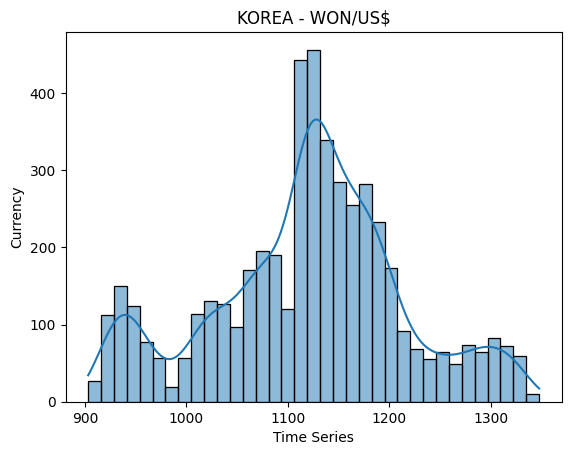

In [23]:
# Reviewing distribution of Korea after outlier removal
sns.histplot(data['KOREA - WON/US$'], kde = True)
plt.title('KOREA - WON/US$')
plt.xlabel("Time Series")
plt.ylabel("Currency")
plt.show()

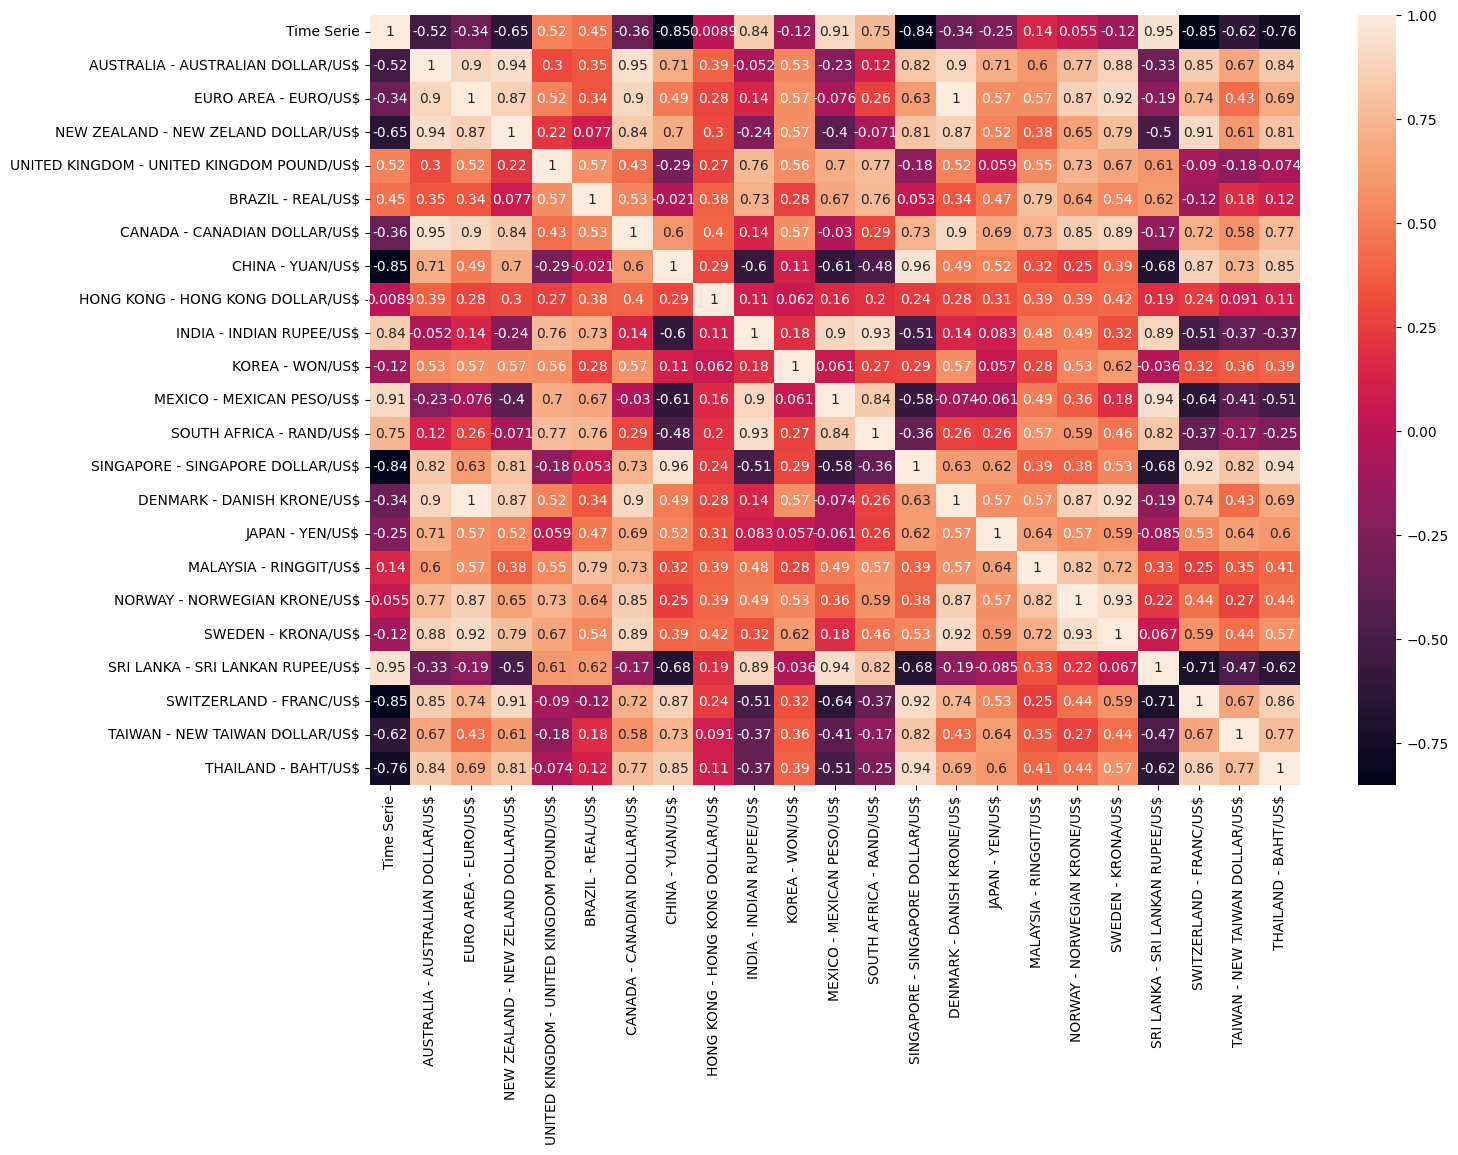

In [24]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(), annot= True)
plt.show()

# **Machine Learning Models**

# **ARIMA**

In [25]:
def ARIMA_func(data, i):
    rmse_scores = []
    mae_scores = []
    mape_scores = []

    # Time series split
    tscv = TimeSeriesSplit(n_splits=5)

    for repeat, (train_index, test_index) in enumerate(tscv.split(data), start=1):

        train_data = data.iloc[train_index]
        test_data = data.iloc[test_index]

        # Fit ARIMA model
        model = ARIMA(train_data[i], order=(5, 1, 0))
        fitted_model = model.fit()

        # Make predictions
        predictions = fitted_model.forecast(steps=len(test_data))

        mae = mean_absolute_error(
            test_data[i],
            predictions
        )

        rmse = root_mean_squared_error(
            test_data[i],
            predictions
        )

        mape = mean_absolute_percentage_error(
            test_data[i],
            predictions
        )

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        mape_scores.append(mape)

        print(
            f"Fold {repeat} | "
            f"RMSE={rmse:.3f} | "
            f"MAE={mae:.3f} | "
            f"MAPE={mape:.3f}"
        )
    average_rmse = np.mean(rmse_scores)
    average_mae = np.mean(mae_scores)
    average_mape = np.mean(mape_scores)

    print(
        f"Average RMSE: {average_rmse:.3f} | "
        f"Average MAE: {average_mae:.3f} | "
        f"Average MAPE: {average_mape:.3f}"
    )


In [29]:
for i in data.columns:
    if i != 'Time Serie':
        print(i)
        ARIMA_func(data, i)

AUSTRALIA - AUSTRALIAN DOLLAR/US$
Fold 1 | RMSE=0.293 | MAE=0.281 | MAPE=0.209
Fold 2 | RMSE=0.177 | MAE=0.154 | MAPE=0.135
Fold 3 | RMSE=0.129 | MAE=0.119 | MAPE=0.123
Fold 4 | RMSE=0.215 | MAE=0.172 | MAPE=0.131
Fold 5 | RMSE=0.070 | MAE=0.057 | MAPE=0.041
Average RMSE: 0.177 | Average MAE: 0.157 | Average MAPE: 0.128
EURO AREA - EURO/US$
Fold 1 | RMSE=0.113 | MAE=0.106 | MAPE=0.132
Fold 2 | RMSE=0.097 | MAE=0.086 | MAPE=0.125
Fold 3 | RMSE=0.038 | MAE=0.032 | MAPE=0.042
Fold 4 | RMSE=0.107 | MAE=0.086 | MAPE=0.098
Fold 5 | RMSE=0.037 | MAE=0.030 | MAPE=0.034
Average RMSE: 0.078 | Average MAE: 0.068 | Average MAPE: 0.086
NEW ZEALAND - NEW ZELAND DOLLAR/US$
Fold 1 | RMSE=0.307 | MAE=0.285 | MAPE=0.193
Fold 2 | RMSE=0.216 | MAE=0.193 | MAPE=0.142
Fold 3 | RMSE=0.194 | MAE=0.178 | MAPE=0.143
Fold 4 | RMSE=0.146 | MAE=0.118 | MAPE=0.085
Fold 5 | RMSE=0.105 | MAE=0.085 | MAPE=0.057
Average RMSE: 0.194 | Average MAE: 0.172 | Average MAPE: 0.124
UNITED KINGDOM - UNITED KINGDOM POUND/US$
Fol

# **XGBoost**

In [26]:
def XGBoost_func(data, i):

    rmse_scores = []
    mae_scores = []
    mape_scores = []

    tscv = TimeSeriesSplit(n_splits=5)

    for repeat, (train_index, test_index) in enumerate(tscv.split(data), start=1):

        train_data = data.iloc[train_index]
        test_data = data.iloc[test_index]

        # Fit XGBoost model
        model = xgb.XGBRegressor()

        model.fit(
            train_data.index.values.reshape(-1, 1),
            train_data[i]
        )

        # Make predictions
        predictions = model.predict(
            test_data.index.values.reshape(-1, 1)
        )

        mae = mean_absolute_error(
            test_data[i],
            predictions
        )

        rmse = root_mean_squared_error(
            test_data[i],
            predictions
        )

        mape = mean_absolute_percentage_error(
            test_data[i],
            predictions
        )

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        mape_scores.append(mape)

        print(
            f"Fold {repeat} | "
            f"RMSE={rmse:.3f} | "
            f"MAE={mae:.3f} | "
            f"MAPE={mape:.3f}"
        )

    average_rmse = np.mean(rmse_scores)
    average_mae = np.mean(mae_scores)
    average_mape = np.mean(mape_scores)

    print(
        f"\nAverage RMSE: {average_rmse:.3f} | "
        f"Average MAE: {average_mae:.3f} | "
        f"Average MAPE: {average_mape:.3f}"
    )

In [45]:
for i in data.columns:
    if i != 'Time Serie':
        print(i)
        XGBoost_func(data, i)

AUSTRALIA - AUSTRALIAN DOLLAR/US$
Fold 1 | RMSE=0.296 | MAE=0.285 | MAPE=0.212
Fold 2 | RMSE=0.171 | MAE=0.147 | MAPE=0.130
Fold 3 | RMSE=0.133 | MAE=0.123 | MAPE=0.126
Fold 4 | RMSE=0.230 | MAE=0.190 | MAPE=0.146
Fold 5 | RMSE=0.077 | MAE=0.060 | MAPE=0.043

Average RMSE: 0.181 | Average MAE: 0.161 | Average MAPE: 0.131
EURO AREA - EURO/US$
Fold 1 | RMSE=0.116 | MAE=0.110 | MAPE=0.136
Fold 2 | RMSE=0.088 | MAE=0.075 | MAPE=0.110
Fold 3 | RMSE=0.038 | MAE=0.032 | MAPE=0.042
Fold 4 | RMSE=0.098 | MAE=0.082 | MAPE=0.094
Fold 5 | RMSE=0.038 | MAE=0.030 | MAPE=0.035

Average RMSE: 0.076 | Average MAE: 0.066 | Average MAPE: 0.083
NEW ZEALAND - NEW ZELAND DOLLAR/US$
Fold 1 | RMSE=0.321 | MAE=0.300 | MAPE=0.203
Fold 2 | RMSE=0.235 | MAE=0.212 | MAPE=0.156
Fold 3 | RMSE=0.179 | MAE=0.162 | MAPE=0.131
Fold 4 | RMSE=0.160 | MAE=0.127 | MAPE=0.090
Fold 5 | RMSE=0.105 | MAE=0.085 | MAPE=0.057

Average RMSE: 0.200 | Average MAE: 0.177 | Average MAPE: 0.127
UNITED KINGDOM - UNITED KINGDOM POUND/US$


In [27]:
def param_tuner(data, target_column, n_splits=5, n_iter=20):

    X = data.drop(columns=[target_column])
    X = data.drop(columns=[target_column, 'Time Serie'])
    y = data[target_column]

    tscv = TimeSeriesSplit(n_splits=n_splits)

    param_grid = {
        "n_estimators": [100, 200, 500],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    }

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    )

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True
    )

    search.fit(X, y)

    results = pd.DataFrame(search.cv_results_)

    print("Best Parameters:")
    print(search.best_params_)

    print(f"\nBest RMSE: {-search.best_score_:.4f}")

    return {
        "best_params": search.best_params_,
        "best_rmse": -search.best_score_,
        "cv_results": results
    }

In [39]:
for i in data.columns:
  result = param_tuner(data, target_column=i)

  best_params = result['best_params']
  best_rmse = result['best_rmse']

  print(i)
  print(best_params)
  print(best_rmse)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

Best RMSE: 90929738748107168.0000
Time Serie
{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
9.092973874810717e+16
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best RMSE: 0.1158
AUSTRALIA - AUSTRALIAN DOLLAR/US$
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
0.11576240350471889
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best RMSE: 0.0307
EURO AREA - EURO/US$
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learni

# **Prophet**

In [28]:
def Prophet_func(data, i):

    rmse_scores = []
    mae_scores = []
    mape_scores = []

    tscv = TimeSeriesSplit(n_splits=5)

    for repeat, (train_index, test_index) in enumerate(tscv.split(data), start=1):

        train_data = data.iloc[train_index][['Time Serie', i]].copy()
        test_data = data.iloc[test_index][['Time Serie', i]].copy()

        # Prophet requires ds and y column names
        train_data.columns = ['ds', 'y']
        test_data.columns = ['ds', 'y']

        # Fit Prophet model
        model = Prophet()
        model.fit(train_data)

        # Predict on test dates
        future = test_data[['ds']]
        forecast = model.predict(future)

        predictions = forecast['yhat'].values

        mae = mean_absolute_error(
            test_data['y'],
            predictions
        )

        rmse = root_mean_squared_error(
            test_data['y'],
            predictions
        )

        mape = mean_absolute_percentage_error(
            test_data['y'],
            predictions
        )

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        mape_scores.append(mape)

        print(
            f"Fold {repeat} | "
            f"RMSE={rmse:.3f} | "
            f"MAE={mae:.3f} | "
            f"MAPE={mape:.3f}"
        )

    average_rmse = np.mean(rmse_scores)
    average_mae = np.mean(mae_scores)
    average_mape = np.mean(mape_scores)

    print(
        f"\nAverage RMSE: {average_rmse:.3f} | "
        f"Average MAE: {average_mae:.3f} | "
        f"Average MAPE: {average_mape:.3f}"
    )

    return average_rmse, average_mae, average_mape

In [25]:
for i in data.columns:
    if i != 'Time Serie':
        print(i)
        Prophet_func(data, i)

AUSTRALIA - AUSTRALIAN DOLLAR/US$


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Fold 1 | RMSE=0.482 | MAE=0.376 | MAPE=0.281


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Fold 2 | RMSE=0.308 | MAE=0.277 | MAPE=0.242


...

Fold 2 | RMSE=3.675 | MAE=3.043 | MAPE=0.094


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Fold 3 | RMSE=5.837 | MAE=5.583 | MAPE=0.183


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Fold 4 | RMSE=3.262 | MAE=2.830 | MAPE=0.083
Fold 5 | RMSE=6.804 | MAE=6.081 | MAPE=0.191

Average RMSE: 4.946 | Average MAE: 4.459 | Average MAPE: 0.134


# **LSTM**

In [37]:
def LSTM_func(data, i):
  scaler = MinMaxScaler()
  scaled_data = scaler.fit_transform(data[i].values.reshape(-1, 1))
  window_size = 12
  X = []
  y = []
  target_dates = data.index[window_size:]

  for i in range(window_size, len(scaled_data)):
      X.append(scaled_data[i - window_size:i, 0])
      y.append(scaled_data[i, 0])

  X = np.array(X)
  y = np.array(y)

  X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
      X, y, target_dates, test_size=0.2, shuffle=False
  )

  X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
  X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
  model = Sequential()
  model.add(LSTM(units=128, return_sequences=True,
            input_shape=(X_train.shape[1], 1)))
  model.add(Dropout(0.2))
  model.add(LSTM(units=128))
  model.add(Dropout(0.2))
  model.add(Dense(1))

  early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
    )

  model.compile(optimizer='adam', loss='mean_squared_error')
  history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose = 0)

  predictions = model.predict(X_test)
  predictions = scaler.inverse_transform(predictions).flatten()
  y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

  rmse_scores = []
  mae_scores = []
  mape_scores = []

  rmse = root_mean_squared_error(y_test, predictions)
  mae = mean_absolute_error(y_test, predictions)
  mape = mean_absolute_percentage_error(y_test, predictions)

  print(
            f"RMSE={rmse:.3f} | "
            f"MAE={mae:.3f} | "
            f"MAPE={mape:.3f}"
        )
  print("Stopped at epoch:", len(history.history['loss']))

  return model

In [40]:
for i in data.columns:
  if i != 'Time Serie':
    print(i)
    LSTM_func(data, i)

AUSTRALIA - AUSTRALIAN DOLLAR/US$
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
RMSE=0.012 | MAE=0.010 | MAPE=0.007
Stopped at epoch: 20
EURO AREA - EURO/US$
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
RMSE=0.008 | MAE=0.006 | MAPE=0.007
Stopped at epoch: 9
NEW ZEALAND - NEW ZELAND DOLLAR/US$
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
RMSE=0.015 | MAE=0.012 | MAPE=0.008
Stopped at epoch: 20
UNITED KINGDOM - UNITED KINGDOM POUND/US$
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
RMSE=0.007 | MAE=0.005 | MAPE=0.007
Stopped at epoch: 20
BRAZIL - REAL/US$
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
RMSE=0.061 | MAE=0.046 | MAPE=0.013
Stopped at epoch: 8
CANADA - CANADIAN DOLLAR/US$
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
RMSE=0.013 | MAE=0.010 | MAPE=0.008
Stopped at epoch: 19
CHINA - YUAN/US$
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
RMSE=0.055 | MAE=0.047 | MAPE=0.007
Stopped at epoch: 7
HONG KONG - HONG KONG DOLLAR/US$
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
RMSE=0.006 | MAE=0.005 | MAPE=0.001
Stopped at epoch: 

In [41]:
AUS_model = LSTM_func(data, 'AUSTRALIA - AUSTRALIAN DOLLAR/US$')
EU_model = LSTM_func(data, 'EURO AREA - EURO/US$')
NZD_model = LSTM_func(data, 'NEW ZEALAND - NEW ZELAND DOLLAR/US$')
GBP_model = LSTM_func(data, 'UNITED KINGDOM - UNITED KINGDOM POUND/US$')
BRL_model = LSTM_func(data, 'BRAZIL - REAL/US$')
CAD_model = LSTM_func(data, 'CANADA - CANADIAN DOLLAR/US$')
CNY_model = LSTM_func(data, 'CHINA - YUAN/US$')
HKD_model = LSTM_func(data, 'HONG KONG - HONG KONG DOLLAR/US$')
INR_model = LSTM_func(data, 'INDIA - INDIAN RUPEE/US$')
KRW_model = LSTM_func(data, 'KOREA - WON/US$')
MXN_model = LSTM_func(data, 'MEXICO - MEXICAN PESO/US$')
ZAR_model = LSTM_func(data, 'SOUTH AFRICA - RAND/US$')
SGD_model = LSTM_func(data, 'SINGAPORE - SINGAPORE DOLLAR/US$')
DKK_model = LSTM_func(data, 'DENMARK - DANISH KRONE/US$')
JPY_model = LSTM_func(data, 'JAPAN - YEN/US$')
MYR_model = LSTM_func(data, 'MALAYSIA - RINGGIT/US$')
NOK_model = LSTM_func(data, 'NORWAY - NORWEGIAN KRONE/US$')
SEK_model = LSTM_func(data, 'SWEDEN - KRONA/US$')
LKR_model = LSTM_func(data, 'SRI LANKA - SRI LANKAN RUPEE/US$')
CHF_model = LSTM_func(data, 'SWITZERLAND - FRANC/US$')
TWD_model = LSTM_func(data, 'TAIWAN - NEW TAIWAN DOLLAR/US$')
THB_model = LSTM_func(data, 'THAILAND - BAHT/US$')

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
RMSE=0.014 | MAE=0.011 | MAPE=0.008
Stopped at epoch: 15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
RMSE=0.007 | MAE=0.005 | MAPE=0.006
Stopped at epoch: 20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
RMSE=0.015 | MAE=0.012 | MAPE=0.009
Stopped at epoch: 20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
RMSE=0.008 | MAE=0.006 | MAPE=0.008
Stopped at epoch: 18
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
RMSE=0.054 | MAE=0.043 | MAPE=0.012
Stopped at epoch: 20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
RMSE=0.015 | MAE=0.012 | MAPE=0.009
Stopped at epoch: 10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
RMSE=0.046 | MAE=0.037 | MAPE=0.005
Stopped at epoch: 8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
RMSE=0.004 | MAE=0.003 | MAPE=0.000
Stopped at epoch: 20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
RMSE=0.403 | MAE=0.292 | MAPE=0.004
Stopped at epoch: 15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
RMSE=8.319 | MAE=6.313 | MAPE=0.006
Stopped at epoch: 20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 2

In [42]:
# Saving Models and Data
AUS_model.save('AUS_model.keras')
EU_model.save('EU_model.keras')
NZD_model.save('NZD_model.keras')
GBP_model.save('GBP_model.keras')
BRL_model.save('BRL_model.keras')
CAD_model.save('CAD_model.keras')
CNY_model.save('CNY_model.keras')
HKD_model.save('HKD_model.keras')
INR_model.save('INR_model.keras')
KRW_model.save('KRW_model.keras')
MXN_model.save('MXN_model.keras')
ZAR_model.save('ZAR_model.keras')
SGD_model.save('SGD_model.keras')
DKK_model.save('DKK_model.keras')
JPY_model.save('JPY_model.keras')
MYR_model.save('MYR_model.keras')
NOK_model.save('NOK_model.keras')
SEK_model.save('SEK_model.keras')
LKR_model.save('LKR_model.keras')
CHF_model.save('CHF_model.keras')
TWD_model.save('TWD_model.keras')
THB_model.save('THB_model.keras')